In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/notebooks/oscarmedina7/detecting-brain-tumors-with-deep-learning/__results__.html
/kaggle/input/notebooks/oscarmedina7/detecting-brain-tumors-with-deep-learning/__notebook__.ipynb
/kaggle/input/notebooks/oscarmedina7/detecting-brain-tumors-with-deep-learning/__output__.json
/kaggle/input/notebooks/oscarmedina7/detecting-brain-tumors-with-deep-learning/besto_model.h5
/kaggle/input/notebooks/oscarmedina7/detecting-brain-tumors-with-deep-learning/custom.css
/kaggle/input/notebooks/oscarmedina7/detecting-brain-tumors-with-deep-learning/__results___files/__results___9_0.png
/kaggle/input/notebooks/oscarmedina7/detecting-brain-tumors-with-deep-learning/__results___files/__results___33_1.png
/kaggle/input/notebooks/oscarmedina7/detecting-brain-tumors-with-deep-learning/__results___files/__results___12_0.png
/kaggle/input/notebooks/oscarmedina7/detecting-brain-tumors-with-deep-learning/__results___files/__results___30_0.png
/kaggle/input/notebooks/oscarmedina7/detecting-brain-tum

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset


In [12]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/masoudnickparvar
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/notumor
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/meningioma
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/glioma
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing/pituitary
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing/notumor
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing/meningioma
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing/glioma
/kaggle/input/notebooks
/kaggle/input/notebooks/gustavoknudsen

In [16]:
train_path = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training'

test_path = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing'

In [18]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [19]:
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [20]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))

model.add(Dropout(0.5))

# 4 classes
model.add(Dense(4,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-18 16:32:30.423834: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [21]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 129s 727ms/step - accuracy: 0.4628 - loss: 1.1986 - val_accuracy: 0.6369 - val_loss: 1.2898
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 100s 570ms/step - accuracy: 0.7342 - loss: 0.6922 - val_accuracy: 0.6781 - val_loss: 1.2346
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 96s 549ms/step - accuracy: 0.7543 - loss: 0.6357 - val_accuracy: 0.6581 - val_loss: 1.4240
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 96s 546ms/step - accuracy: 0.7877 - loss: 0.5406 - val_accuracy: 0.7031 - val_loss: 1.1056
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 95s 543ms/step - accuracy: 0.8041 - loss: 0.5067 - val_accuracy: 0.7175 - val_loss: 1.1653
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 97s 553ms/step - accuracy: 0.8145 - loss: 0.4802 - val_accuracy: 0.7106 - val_loss: 1.2030
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 95s 543ms/step - accuracy: 0.8320 - loss: 0.4410 - val_accuracy: 0.6750 - val_loss: 1.4552
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 95s 540ms/step - accuracy: 0.8324 - loss:

In [23]:
loss, accuracy = model.evaluate(test_data)

print("Accuracy:", accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - accuracy: 0.7286 - loss: 1.2551
Accuracy: 0.7300000190734863


In [24]:
model.save("brain_model.h5")

print("Brain Tumor Model Saved Successfully")

Brain Tumor Model Saved Successfully


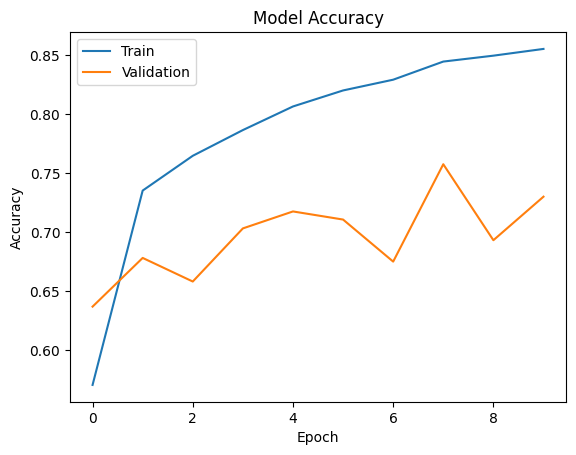

In [25]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()